In [1]:
# Caso "Hacienda El Jobo"
# Sesión A: Importando y Preparando Datos

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
eljobo = pd.read_csv('LitrosPorVaca.csv', delimiter = ";")

In [4]:
eljobo.head()

,Mes,Litros por vaca
0,2007-1,21.6
1,2007-2,20.6
2,2007-3,23.5
3,2007-4,24.1
4,2007-5,26.7


In [5]:
eljobo.tail()

,Mes,Litros por vaca
163,2020-8,31.5
164,2020-9,30.0
165,2020-10,30.4
166,2020-11,29.3
167,2020-12,30.9


In [6]:
eljobo['Mes'] = pd.to_datetime(eljobo['Mes'])

In [7]:
eljobo.head()

,Mes,Litros por vaca
0,2007-01-01,21.6
1,2007-02-01,20.6
2,2007-03-01,23.5
3,2007-04-01,24.1
4,2007-05-01,26.7


In [8]:
eljobo.set_index('Mes', inplace = True)

In [9]:
eljobo.index

DatetimeIndex(['2007-01-01', '2007-02-01', '2007-03-01', '2007-04-01',
               '2007-05-01', '2007-06-01', '2007-07-01', '2007-08-01',
               '2007-09-01', '2007-10-01',
               ...
               '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01',
               '2020-11-01', '2020-12-01'],
              dtype='datetime64[ns]', name='Mes', length=168, freq=None)

In [10]:
eljobo.describe()

,Litros por vaca
count,168.000000
mean,27.698214
std,3.750968
min,20.300000
25%,24.875000
50%,27.950000
75%,30.225000
max,35.600000


In [11]:
# Paso 2: Grafico

<AxesSubplot:xlabel='Mes'>

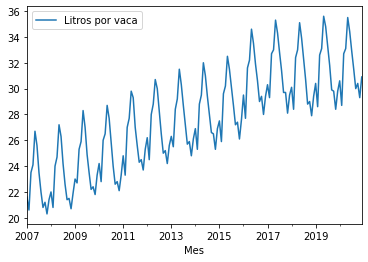

In [12]:
eljobo.plot()

In [13]:
seriedetiempo = eljobo['Litros por vaca']

In [14]:
type(seriedetiempo)

pandas.core.series.Series

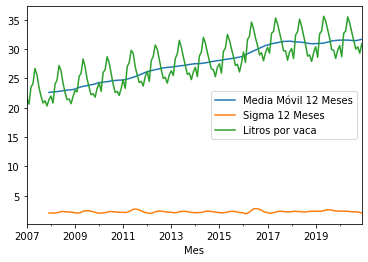

In [15]:
seriedetiempo.rolling(12).mean().plot(label = 'Media Móvil 12 Meses')
seriedetiempo.rolling(12).std().plot(label = 'Sigma 12 Meses')
seriedetiempo.plot()
plt.legend()

In [16]:
#Paso 3: Descomposición Estacional

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [18]:
estacional = seasonal_decompose(seriedetiempo, period = 12)

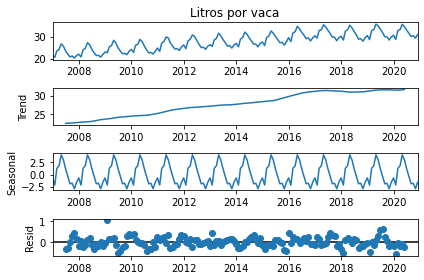

In [19]:
grafico = estacional.plot()

In [20]:
from statsmodels.tsa.stattools import adfuller

In [21]:
resultado = adfuller(eljobo['Litros por vaca'])

In [22]:
resultado

(-1.276568344979716,
 0.6398229938263109,
 13,
 154,
 {'1%': -3.473542528196209,
  '5%': -2.880497674144038,
  '10%': -2.576878053634677},
 108.01757657878653)

In [23]:
def prueba_adf(time_series):
    resultado = adfuller(time_series)
    print("Prueba Dicky-Fuller Aumentado")
    labels = ['Estadístico ADF', 'p-value', '# de retrasos', 'Observaciones utilizadas']
    for valor, label in zip(resultado, labels):
        print(label + ":" + str(valor))
        
    if resultado[1] <= 0.05:
        print("Se rechaza la hipótesis nula")
        print("Los datos son estacionarios")
    else:
        print("No se puede rechazar hipótesis nula")
        print("Los datos no son estacionarios")

In [24]:
prueba_adf(eljobo['Litros por vaca'])

Prueba Dicky-Fuller Aumentado
Estadístico ADF:-1.276568344979716
p-value:0.6398229938263109
# de retrasos:13
Observaciones utilizadas:154
No se puede rechazar hipótesis nula
Los datos no son estacionarios


In [25]:
# Análisis con Diferencias

In [26]:
eljobo['Primera Diferencia'] = eljobo['Litros por vaca'] - eljobo['Litros por vaca'].shift(1)

<AxesSubplot:xlabel='Mes'>

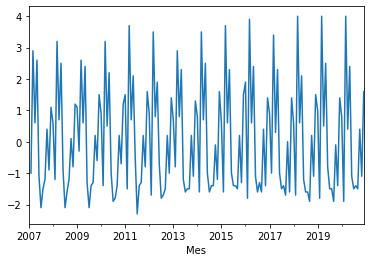

In [27]:
eljobo['Primera Diferencia'].plot()

In [28]:
prueba_adf(eljobo['Primera Diferencia'].dropna())

Prueba Dicky-Fuller Aumentado
Estadístico ADF:-3.0400402173071717
p-value:0.03132059202472912
# de retrasos:14
Observaciones utilizadas:152
Se rechaza la hipótesis nula
Los datos son estacionarios


In [29]:
eljobo['Segunda Diferencia'] = eljobo['Litros por vaca'] - eljobo['Litros por vaca'].shift(2)

<AxesSubplot:xlabel='Mes'>

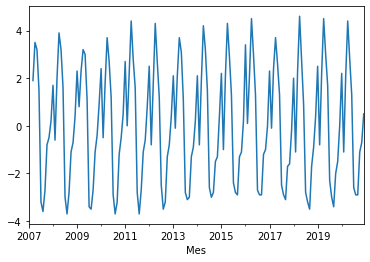

In [30]:
eljobo['Segunda Diferencia'].plot()

In [31]:
prueba_adf(eljobo['Segunda Diferencia'].dropna())

Prueba Dicky-Fuller Aumentado
Estadístico ADF:-3.052586159739641
p-value:0.03026687172218071
# de retrasos:13
Observaciones utilizadas:152
Se rechaza la hipótesis nula
Los datos son estacionarios


In [32]:
eljobo['Diferencia Estacionalidad'] = eljobo['Litros por vaca'] - eljobo['Litros por vaca'].shift(12)

<AxesSubplot:xlabel='Mes'>

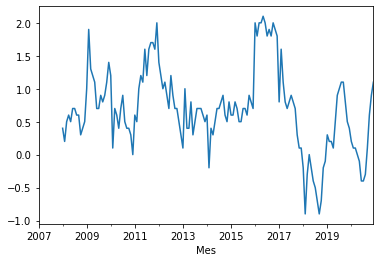

In [33]:
eljobo['Diferencia Estacionalidad'].plot()

In [34]:
prueba_adf(eljobo['Diferencia Estacionalidad'].dropna())

Prueba Dicky-Fuller Aumentado
Estadístico ADF:-2.440963411044127
p-value:0.130506895958515
# de retrasos:12
Observaciones utilizadas:143
No se puede rechazar hipótesis nula
Los datos no son estacionarios


In [35]:
eljobo['Primera Diferencia con Estacionalidad'] = eljobo['Primera Diferencia'] - eljobo['Primera Diferencia'].shift(12)

<AxesSubplot:xlabel='Mes'>

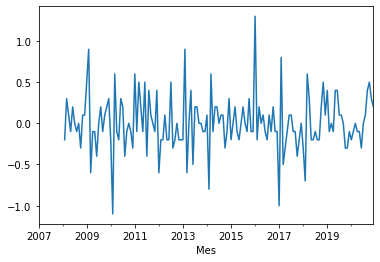

In [36]:
eljobo['Primera Diferencia con Estacionalidad'].plot()

In [37]:
prueba_adf(eljobo['Primera Diferencia con Estacionalidad'].dropna())

Prueba Dicky-Fuller Aumentado
Estadístico ADF:-4.875965841800421
p-value:3.883227114341177e-05
# de retrasos:11
Observaciones utilizadas:143
Se rechaza la hipótesis nula
Los datos son estacionarios


In [38]:
# Partiendo la base

In [39]:
eljobo

,Litros por vaca,Primera Diferencia,Segunda Diferencia,Diferencia Estacionalidad,Primera Diferencia con Estacionalidad
Mes,,,,,
2007-01-01,21.6,NaN,NaN,NaN,NaN
2007-02-01,20.6,-1.0,NaN,NaN,NaN
2007-03-01,23.5,2.9,1.9,NaN,NaN
2007-04-01,24.1,0.6,3.5,NaN,NaN
2007-05-01,26.7,2.6,3.2,NaN,NaN
...,...,...,...,...,...
2020-08-01,31.5,-1.4,-2.9,-0.3,0.1
2020-09-01,30.0,-1.5,-2.9,0.1,0.4
2020-10-01,30.4,0.4,-1.1,0.6,0.5


In [40]:
eljoboA = eljobo[0:156]

In [41]:
eljoboA

,Litros por vaca,Primera Diferencia,Segunda Diferencia,Diferencia Estacionalidad,Primera Diferencia con Estacionalidad
Mes,,,,,
2007-01-01,21.6,NaN,NaN,NaN,NaN
2007-02-01,20.6,-1.0,NaN,NaN,NaN
2007-03-01,23.5,2.9,1.9,NaN,NaN
2007-04-01,24.1,0.6,3.5,NaN,NaN
2007-05-01,26.7,2.6,3.2,NaN,NaN
...,...,...,...,...,...
2019-08-01,31.8,-1.5,-3.0,1.1,1.000000e-01
2019-09-01,29.9,-1.9,-3.4,1.1,-3.552714e-15
2019-10-01,29.8,-0.1,-2.0,0.8,-3.000000e-01


In [42]:
eljoboB = eljobo[156:168]

In [43]:
eljoboB

,Litros por vaca,Primera Diferencia,Segunda Diferencia,Diferencia Estacionalidad,Primera Diferencia con Estacionalidad
Mes,,,,,
2020-01-01,30.6,0.8,2.2,0.2,-2.000000e-01
2020-02-01,28.7,-1.9,-1.1,0.1,-1.000000e-01
2020-03-01,32.7,4.0,2.1,0.1,3.552714e-15
2020-04-01,33.1,0.4,4.4,0.0,-1.000000e-01
2020-05-01,35.5,2.4,2.8,-0.1,-1.000000e-01
2020-06-01,34.4,-1.1,1.3,-0.4,-3.000000e-01
2020-07-01,32.9,-1.5,-2.6,-0.4,0.000000e+00
2020-08-01,31.5,-1.4,-2.9,-0.3,1.000000e-01
2020-09-01,30.0,-1.5,-2.9,0.1,4.000000e-01


In [44]:
# Gráficos ACF y PACF

In [45]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

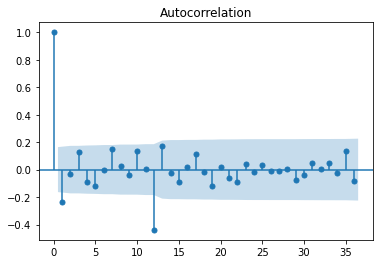

In [46]:
grafico1 = plot_acf(eljoboA['Primera Diferencia con Estacionalidad'].dropna(), lags = 36)

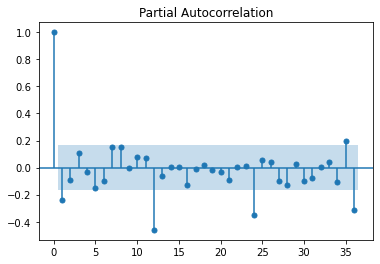

In [47]:
grafico2 = plot_pacf(eljoboA['Primera Diferencia con Estacionalidad'].dropna(), lags = 36)

In [161]:
# Modelo ARIMA

In [162]:
from statsmodels.tsa.arima_model import ARIMA

In [163]:
modelo = sm.tsa.statespace.SARIMAX(eljoboA['Litros por vaca'], order = (2,1,2), seasonal_order = (2,1,1,12))

C:\Users\User\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\User\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'


In [164]:
resultados = modelo.fit()

In [165]:
print(resultados.summary())
# P = 3 AIC 47.576
# P = 1 AIC 49.777
# P = 2 AIC 51.212

                                      SARIMAX Results                                       
Dep. Variable:                      Litros por vaca   No. Observations:                  156
Model:             SARIMAX(2, 1, 2)x(2, 1, [1], 12)   Log Likelihood                 -17.606
Date:                              Fri, 01 Oct 2021   AIC                             51.212
Time:                                      07:41:00   BIC                             74.915
Sample:                                  01-01-2007   HQIC                            60.844
                                       - 12-01-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3699      0.502     -0.737      0.461      -1.354       0.614
ar.L2         -0.50

<AxesSubplot:xlabel='Mes'>

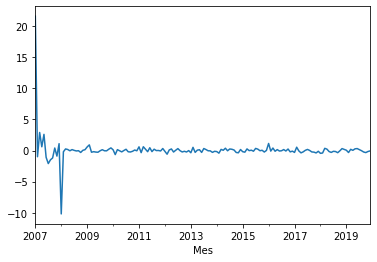

In [166]:
resultados.resid.plot()

In [167]:
# Pronostico con ARIMA

In [168]:
eljoboA['pronostico'] = resultados.predict()

<ipython-input-168-d86a4ea5c6a7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eljoboA['pronostico'] = resultados.predict()


In [169]:
eljoboA

,Litros por vaca,Primera Diferencia,Segunda Diferencia,Diferencia Estacionalidad,Primera Diferencia con Estacionalidad,pronostico
Mes,,,,,,
2007-01-01,21.6,NaN,NaN,NaN,NaN,0.000000
2007-02-01,20.6,-1.0,NaN,NaN,NaN,21.600000
2007-03-01,23.5,2.9,1.9,NaN,NaN,20.600000
2007-04-01,24.1,0.6,3.5,NaN,NaN,23.500000
2007-05-01,26.7,2.6,3.2,NaN,NaN,24.100000
...,...,...,...,...,...,...
2019-08-01,31.8,-1.5,-3.0,1.1,1.000000e-01,31.827754
2019-09-01,29.9,-1.9,-3.4,1.1,-3.552714e-15,30.138917
2019-10-01,29.8,-0.1,-2.0,0.8,-3.000000e-01,30.132877


<AxesSubplot:xlabel='Mes'>

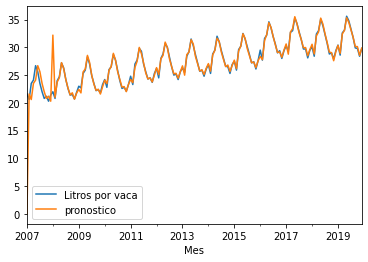

In [170]:
eljoboA[['Litros por vaca', 'pronostico']].plot()

In [171]:
# Agregar filas con fechas futuras

In [172]:
from pandas.tseries.offsets import DateOffset

In [173]:
fechasfuturas = [eljoboA.index[-1] + DateOffset(months = x) for x in range(1,13)]

In [174]:
fechasfuturas

[Timestamp('2020-01-01 00:00:00'),
 Timestamp('2020-02-01 00:00:00'),
 Timestamp('2020-03-01 00:00:00'),
 Timestamp('2020-04-01 00:00:00'),
 Timestamp('2020-05-01 00:00:00'),
 Timestamp('2020-06-01 00:00:00'),
 Timestamp('2020-07-01 00:00:00'),
 Timestamp('2020-08-01 00:00:00'),
 Timestamp('2020-09-01 00:00:00'),
 Timestamp('2020-10-01 00:00:00'),
 Timestamp('2020-11-01 00:00:00'),
 Timestamp('2020-12-01 00:00:00')]

In [175]:
df_futura = pd.DataFrame(index=fechasfuturas, columns = eljoboA.columns)

In [176]:
df_futura

,Litros por vaca,Primera Diferencia,Segunda Diferencia,Diferencia Estacionalidad,Primera Diferencia con Estacionalidad,pronostico
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-07-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-01,NaN,NaN,NaN,NaN,NaN,NaN


In [177]:
nuevojoboA = pd.concat([eljoboA, df_futura])

In [178]:
nuevojoboA

,Litros por vaca,Primera Diferencia,Segunda Diferencia,Diferencia Estacionalidad,Primera Diferencia con Estacionalidad,pronostico
2007-01-01,21.6,NaN,NaN,NaN,NaN,0.0
2007-02-01,20.6,-1.0,NaN,NaN,NaN,21.6
2007-03-01,23.5,2.9,1.9,NaN,NaN,20.6
2007-04-01,24.1,0.6,3.5,NaN,NaN,23.5
2007-05-01,26.7,2.6,3.2,NaN,NaN,24.1
...,...,...,...,...,...,...
2020-08-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-01,NaN,NaN,NaN,NaN,NaN,NaN


In [179]:
nuevojoboA['pronostico'] = resultados.predict(start = 156, end = 168)

In [180]:
nuevojoboA

,Litros por vaca,Primera Diferencia,Segunda Diferencia,Diferencia Estacionalidad,Primera Diferencia con Estacionalidad,pronostico
2007-01-01,21.6,NaN,NaN,NaN,NaN,NaN
2007-02-01,20.6,-1.0,NaN,NaN,NaN,NaN
2007-03-01,23.5,2.9,1.9,NaN,NaN,NaN
2007-04-01,24.1,0.6,3.5,NaN,NaN,NaN
2007-05-01,26.7,2.6,3.2,NaN,NaN,NaN
...,...,...,...,...,...,...
2020-08-01,NaN,NaN,NaN,NaN,NaN,31.838735
2020-09-01,NaN,NaN,NaN,NaN,NaN,30.057292
2020-10-01,NaN,NaN,NaN,NaN,NaN,30.120906
2020-11-01,NaN,NaN,NaN,NaN,NaN,28.767410


<AxesSubplot:>

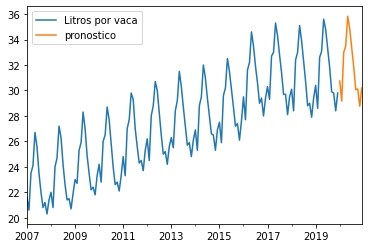

In [181]:
nuevojoboA[['Litros por vaca', 'pronostico']].plot()

In [182]:
nuevojoboA['pronostico'][156:168]

2020-01-01    30.747078
2020-02-01    29.169231
2020-03-01    32.986928
2020-04-01    33.493694
2020-05-01    35.832411
2020-06-01    34.851339
2020-07-01    33.313760
2020-08-01    31.838735
2020-09-01    30.057292
2020-10-01    30.120906
2020-11-01    28.767410
2020-12-01    30.199048
Name: pronostico, dtype: float64

In [183]:
# Validación del Modelo: Cálculo del RMSE

<AxesSubplot:xlabel='Mes'>

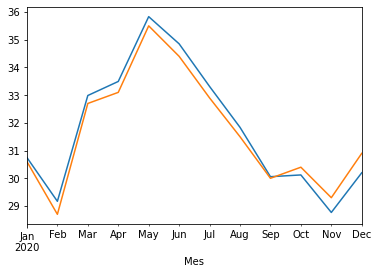

In [184]:
nuevojoboA['pronostico'][156:168].plot()
eljoboB['Litros por vaca'].plot()

In [185]:
from sklearn.metrics import mean_squared_error

In [186]:
rmse = np.sqrt(mean_squared_error(eljoboB['Litros por vaca'], nuevojoboA['pronostico'][156:168]))

In [187]:
rmse

0.4016046719197366

In [188]:
# Tarea RMSE
# order = (2,1,2), seasonal_order = (3,1,1,12): 0.5200106824510301
# order = (2,1,2), seasonal_order = (1,1,1,12): 0.38870849562540055
# order = (2,1,2), seasonal_order = (2,1,1,12): 0.4016046719197366